# Lesson 16 activity: feature engineering

## Notebook setup

This example notebook demonstrates a common pitfall in dimensionality reduction: including the target variable (`MedHouseVal`) in a PCA transformation. This creates data leakage, which produces erroneously high model performance scores. Read the reflection section at the bottom to understand what went wrong.

**Your task**: Apply at least two different feature engineering techniques to the `housing_df` dataframe to improve the dataset. At the end of the notebook, your engineered dataset and the original dataset will be used to train a linear regression model to predict `MedHouseVal`. Your goal is to achieve better model performance via feature engineering.

Don't change any of the code in the Model evaluation section of the notebook, especially the output saving. Otherwise the leaderboard scoring may not work!

Before applying transformations, explore the dataset to understand what techniques might be most beneficial.

### Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set random seed for reproducibility
np.random.seed(315)

### Load dataset

In [2]:
# Load California housing dataset
original_housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv')
housing_df = original_housing_df.copy()

## Task 1: Explore the dataset

Before deciding what feature engineering techniques to apply, explore the dataset to understand its characteristics.

In [3]:
print(housing_df.shape)
print()
housing_df.info()
print()
housing_df.describe()

(20640, 9)

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


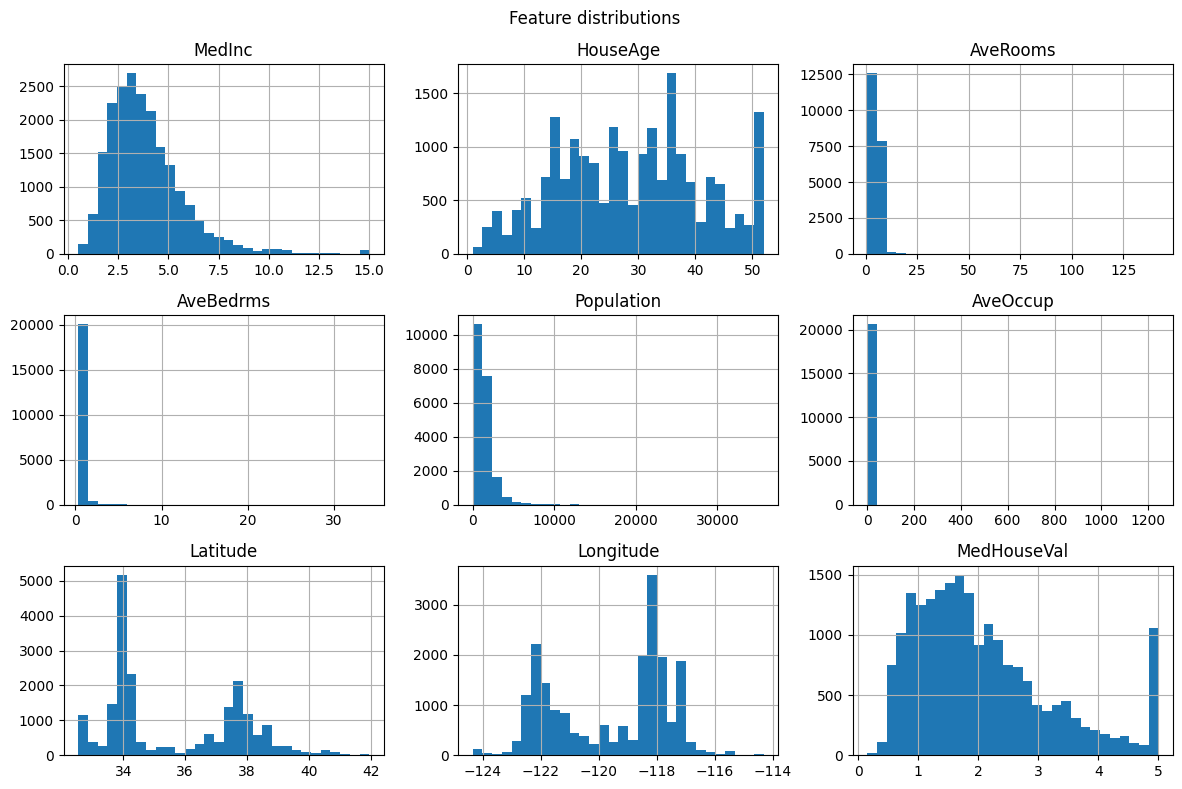

In [4]:
housing_df.hist(figsize=(12, 8), bins=30)
plt.suptitle('Feature distributions')
plt.tight_layout()
plt.show()

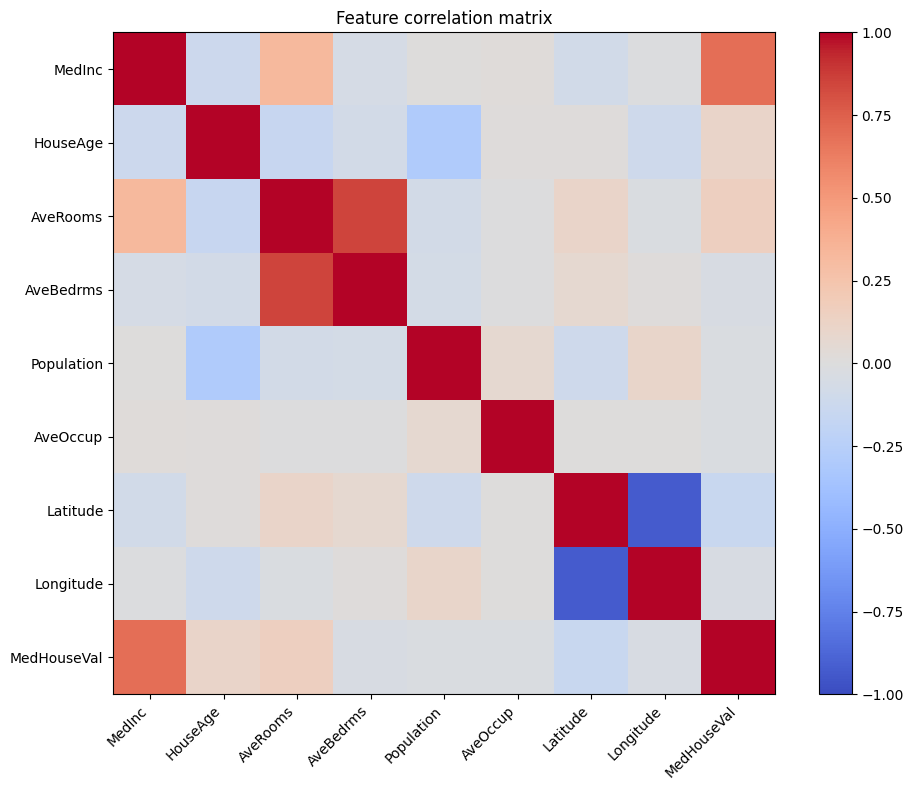

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = housing_df.corr()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

## Task 2: Apply your first feature engineering technique

Before applying PCA, we need to put all columns on the same scale. Without scaling, features with large numerical ranges (such as `Population`) would dominate the principal components due to their larger variance.

We apply `StandardScaler` to transform all columns to zero mean and unit variance.

In [6]:
# Scale all columns to prepare for PCA
scaler = StandardScaler()
scaled_values = scaler.fit_transform(housing_df)
housing_df = pd.DataFrame(scaled_values, columns=housing_df.columns)

print('Scaled dataset statistics (should all be near mean=0, std=1):')
housing_df.describe().round(3)

Scaled dataset statistics (should all be near mean=0, std=1):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.774,-2.196,-1.852,-1.611,-1.256,-0.229,-1.448,-2.386,-1.663
25%,-0.688,-0.845,-0.399,-0.191,-0.564,-0.062,-0.797,-1.113,-0.756
50%,-0.177,0.029,-0.081,-0.101,-0.229,-0.024,-0.642,0.539,-0.235
75%,0.459,0.664,0.252,0.006,0.264,0.020,0.973,0.778,0.501
max,5.858,1.856,55.163,69.572,30.250,119.419,2.958,2.625,2.540


## Task 3: Apply your second feature engineering technique

Now we apply PCA to reduce the dimensionality of the dataset. PCA finds the directions of greatest variance and projects the data onto those directions, producing a compact set of uncorrelated features.

We keep 8 of the 9 principal components, retaining most of the variance while reducing dimensionality by one.

In [7]:
# Apply PCA to all scaled columns
pca = PCA(n_components=8)
pc_scores = pca.fit_transform(housing_df)

print(f'Variance explained by 8 components: {pca.explained_variance_ratio_.sum():.4f}')
print('Per-component variance ratio:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i + 1}: {var:.4f}')

# Reconstruct housing_df with PC features and restore the original label
pc_cols = [f'PC{i + 1}' for i in range(8)]
housing_df = pd.DataFrame(pc_scores, columns=pc_cols)
housing_df['MedHouseVal'] = original_housing_df['MedHouseVal'].values

Variance explained by 8 components: 0.9951
Per-component variance ratio:
  PC1: 0.2263
  PC2: 0.2195
  PC3: 0.1791
  PC4: 0.1411
  PC5: 0.1115
  PC6: 0.0769
  PC7: 0.0337
  PC8: 0.0071


## Model evaluation

Now we'll compare model performance on the original dataset versus your engineered dataset.

### Evaluate datasets

In [8]:
# Create output directory if it doesn't exist
output_directory = 'data/outputs'
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Save a copy of the engineered dataframe
housing_df.to_csv('data/outputs/housing_df.csv', index=False)

In [9]:
# Create linear regression model
model = LinearRegression()

# Evaluate on original dataset
scores_original = cross_val_score(
    model,
    original_housing_df.drop('MedHouseVal', axis=1),
    original_housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

# Evaluate on engineered dataset
scores_engineered = cross_val_score(
    model,
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

engineered_mean = scores_engineered.mean()
original_mean = scores_original.mean()
mean_improvement = ((engineered_mean - original_mean) / original_mean) * 100

print(f'\nMean improvement: {mean_improvement:.2f}%')


Mean improvement: 95.60%


### Visualize model performance comparison

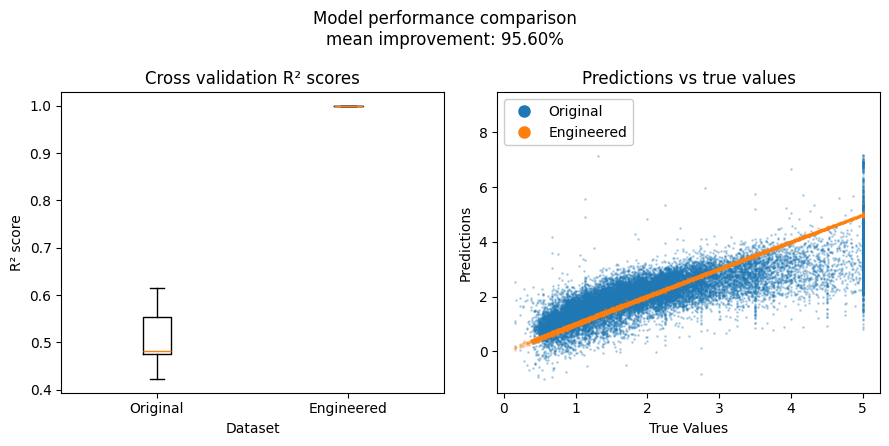

In [10]:
original_model = LinearRegression()
original_model.fit(original_housing_df.drop('MedHouseVal', axis=1), original_housing_df['MedHouseVal'])
original_predictions = original_model.predict(original_housing_df.drop('MedHouseVal', axis=1))

model = LinearRegression()
model.fit(housing_df.drop('MedHouseVal', axis=1), housing_df['MedHouseVal'])
predictions = model.predict(housing_df.drop('MedHouseVal', axis=1))

# Create boxplot comparing performance
data_to_plot = [scores_original, scores_engineered]
labels = ['Original', 'Engineered']

fig, axs = plt.subplots(1, 2, figsize=(9,4.5))

fig.suptitle(f'Model performance comparison\nmean improvement: {mean_improvement:.2f}%')

axs[0].set_title('Cross validation R\u00b2 scores')
axs[0].boxplot(data_to_plot, tick_labels=labels)
axs[0].set_xlabel('Dataset')
axs[0].set_ylabel('R\u00b2 score')

axs[1].set_title('Predictions vs true values')
axs[1].plot(
    original_housing_df['MedHouseVal'], original_predictions,
    'o', markersize=1, label='Original', alpha=0.25
)

axs[1].plot(
    housing_df['MedHouseVal'], predictions,
    'o', markersize=1, label='Engineered', alpha=0.25
)

axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predictions')

leg = axs[1].legend(loc='upper left', markerscale=8, framealpha=1)

for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

## Reflection

### What went wrong

This notebook demonstrates **data leakage** caused by including the target variable in a PCA transformation.

**The mistake**: In Task 2, `StandardScaler` was applied to all columns — including `MedHouseVal`. In Task 3, PCA was then applied to the full scaled dataframe (which still contained the scaled `MedHouseVal` column). Each of the 8 resulting principal components is therefore a linear combination of all 9 original columns, including the target.

**Why this inflates performance**: When the linear regression model predicts `MedHouseVal` from these principal components, it is partly predicting a variable from features that already encode that variable. The model doesn't need to learn the feature-target relationship — the target has already leaked into the features during the PCA step.

**How to fix it**: Transformations must only be applied to the feature columns. The target variable should never be included:

```python
feature_cols = housing_df.drop('MedHouseVal', axis=1).columns.tolist()

scaler = StandardScaler()
housing_df[feature_cols] = scaler.fit_transform(housing_df[feature_cols])

pca = PCA(n_components=7)
pc_scores = pca.fit_transform(housing_df[feature_cols])
pc_cols = [f'PC{i + 1}' for i in range(7)]
housing_df = pd.DataFrame(pc_scores, columns=pc_cols)
housing_df['MedHouseVal'] = original_housing_df['MedHouseVal'].values
```

With this corrected version, PCA operates only on the 8 feature columns — no leakage occurs and any performance gain is genuine.